# Práctica 3 — Generalized Predictive Control (GPC)

**Curso: Fundamentos del Control Predictivo basado en Modelo (MPC) y su uso en la industria**

En esta práctica se implementa un **Generalized Predictive Control (GPC)** en Python / Google Colab utilizando como planta el mismo tanque empleado en las prácticas anteriores.

A diferencia de MAC y DMC, el GPC estudiado aquí utiliza directamente un modelo en función de transferencia de tipo **CARIMA**. La práctica desarrolla explícitamente:

1. el modelo CARIMA;
2. la ecuación diofántica;
3. los polinomios $E_j(z^{-1})$, $F_j(z^{-1})$ y $G_j(z^{-1})$;
4. el predictor vectorial;
5. las matrices $G$ y $F$;
6. la función objetivo cuadrática;
7. la ley de control analítica sin restricciones;
8. el horizonte deslizante;
9. el efecto del horizonte $h$, de $\lambda$ y del filtrado de referencia.


> **Dinámica recomendada:** antes de ejecutar cada experimento, analice la pregunta asociada y realice una predicción cualitativa. Después, ejecute la celda, compare el resultado con la predicción y despliegue la respuesta razonada.  
> Las respuestas están ocultas en bloques desplegables para poder relizar un análisis pausado.

## Objetivos

Al finalizar la práctica se debería ser capaz de:

- interpretar un modelo CARIMA;
- relacionar la función de transferencia discreta con los polinomios $A(z^{-1})$ y $B(z^{-1})$;
- resolver la ecuación diofántica del predictor;
- construir los polinomios $E_j(z^{-1})$, $F_j(z^{-1})$ y $G_j(z^{-1})$;
- construir el predictor

\begin{align*}
\hat{\mathbf y}
=
G\Delta\mathbf u^+
+
\mathbf f;
\end{align*}

- calcular la respuesta libre a partir de las salidas pasadas;
- obtener la ley de control GPC sin restricciones;
- estudiar el efecto de $h$, $\lambda$ y del filtro de referencia;
- identificar las principales diferencias prácticas entre GPC y los modelos de convolución empleados en MAC y DMC.

## 1. Librerías

Se utilizan `NumPy`, `SciPy` y `Matplotlib`, disponibles de forma estándar en Google Colab.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

np.set_printoptions(precision=6, suppress=True)

## 2. Planta: tanque de almacenamiento

Las transparencias de GPC utilizan el mismo tanque de descarga por gravedad:


![My Image](https://github.com/GICI-UPV-EHU/Imagenes_GICI/blob/main/Procesos/Tanque.png?raw=true)


\begin{align*}
A_t\frac{dh(t)}{dt}
=
q(t)-q_1(t),
\end{align*}

con flujo laminar

\begin{align*}
q_1(t)=K_t h(t).
\end{align*}

Por tanto,

\begin{align*}
A_t\frac{dh(t)}{dt}
+
K_t h(t)
=
q(t).
\end{align*}

Para los parámetros

\begin{align*}
A_t&=1, \\
K_t&=0.5,
\end{align*}

se obtiene

\begin{align*}
G(s)
=
\frac{H(s)}{Q(s)}
=
\frac{1}{s+0.5}.
\end{align*}

En esta práctica se establece un periodo de muestreo

\begin{align*}
T_d=0.05\;\text{min}.
\end{align*}

In [2]:
At = 1.0
Kt = 0.5
Td = 0.05

G_cont = signal.TransferFunction([1.0], [At, Kt])

A_ss = np.array([[-Kt / At]])
B_ss = np.array([[1.0 / At]])
C_ss = np.array([[1.0]])
D_ss = np.array([[0.0]])

Ad_m, Bd_m, Cd_m, Dd_m, _ = signal.cont2discrete(
    (A_ss, B_ss, C_ss, D_ss),
    Td,
    method="zoh"
)

Ad = float(Ad_m[0, 0])
Bd = float(Bd_m[0, 0])
Cd = float(Cd_m[0, 0])
Dd = float(Dd_m[0, 0])

print(f"Ad = {Ad:.8f}")
print(f"Bd = {Bd:.8f}")
print()
print("Modelo discreto:")
print(f"h(k+1) = {Ad:.8f} h(k) + {Bd:.8f} q(k)")

Ad = 0.97530991
Bd = 0.04938018

Modelo discreto:
h(k+1) = 0.97530991 h(k) + 0.04938018 q(k)


### Preguntas para dinamizar — proceso y discretización

> **Pregunta 1.** Sin calcular todavía el modelo discreto, ¿qué altura estacionaria produciría un caudal constante $q=1$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

En régimen estacionario,

\begin{align*}
q=K_t h.
\end{align*}

Con $K_t=0.5$,

\begin{align*}
h_{\mathrm{ss}}=\frac{1}{0.5}=2.
\end{align*}

</details>

> **Pregunta 2.** ¿Cuál es la constante de tiempo del tanque?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Es

\begin{align*}
\tau=\frac{A_t}{K_t}
=\frac{1}{0.5}
=2\ \text{min}.
\end{align*}

</details>

> **Pregunta 3.** Con $T_d=0.05$ min, ¿cuántas muestras tenemos aproximadamente por constante de tiempo?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

\begin{align*}
\frac{\tau}{T_d}
=
\frac{2}{0.05}
=
40.
\end{align*}

Se trata de un muestreo bastante fino respecto a la dinámica dominante.

</details>

> **Pregunta 4.** ¿Qué ocurriría si aumentásemos mucho $T_d$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Disminuiría la resolución temporal y el controlador actualizaría sus decisiones con menor frecuencia. Aunque la discretización ZOH sea exacta en los instantes de muestreo, el periodo podría resultar inadecuado para control.

</details>

In [3]:
# Experimento en directo: efecto del periodo de muestreo
tau = At / Kt

for Td_test in [0.02, 0.05, 0.10, 0.20, 0.50]:
    Ad_t, Bd_t, _, _, _ = signal.cont2discrete(
        (A_ss, B_ss, C_ss, D_ss),
        Td_test,
        method="zoh"
    )
    print(
        f"Td={Td_test:4.2f} min   "
        f"muestras/tau={tau/Td_test:6.1f}   "
        f"Ad={Ad_t[0,0]:.6f}   "
        f"Bd={Bd_t[0,0]:.6f}"
    )

Td=0.02 min   muestras/tau= 100.0   Ad=0.990050   Bd=0.019900
Td=0.05 min   muestras/tau=  40.0   Ad=0.975310   Bd=0.049380
Td=0.10 min   muestras/tau=  20.0   Ad=0.951229   Bd=0.097541
Td=0.20 min   muestras/tau=  10.0   Ad=0.904837   Bd=0.190325
Td=0.50 min   muestras/tau=   4.0   Ad=0.778801   Bd=0.442398


> **Pregunta 5.** ¿Por qué $A_d$ se aproxima a 1 cuando $T_d$ se hace pequeño?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque en un intervalo muy corto el estado varía poco:

\begin{align*}
A_d=e^{-T_d/\tau}
\longrightarrow 1
\qquad
\text{cuando }T_d\to0.
\end{align*}

</details>

> **Pregunta 6.** ¿Por qué en esta práctica se utiliza $T_d=0.05$ y no el $T_d=0.2$ de las prácticas MAC/DMC?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque esta práctica reproduce el ejemplo GPC de las transparencias, donde se emplea $T_d=0.05$ min. No se trata de afirmar que $0.05$ sea universalmente mejor, sino de mantener la configuración del ejemplo que se desea analizar.

</details>

El modelo obtenido es, aproximadamente,

\begin{align*}
G_d(z^{-1})
=
\frac{0.0494z^{-1}}
     {1-0.9753z^{-1}},
\end{align*}

que coincide con el utilizado en las transparencias del ejemplo.

## 3. Modelo CARIMA

La formulación GPC utiliza el modelo

\begin{align*}
A(z^{-1})y(t)
=
B(z^{-1})z^{-d}u(t-1)
+
C(z^{-1})
\frac{e(t)}
     {1-z^{-1}}.
\end{align*}

Los polinomios son

\begin{align*}
A(z^{-1})
&=
1+a_1z^{-1}+\cdots+a_{n_a}z^{-n_a}, \\
B(z^{-1})
&=
b_0+b_1z^{-1}+\cdots+b_{n_b}z^{-n_b}.
\end{align*}

En esta práctica se supone ruido blanco:

\begin{align*}
C(z^{-1})=1.
\end{align*}

Para el tanque,

\begin{align*}
A(z^{-1})
&=
1-0.9753z^{-1}, \\
B(z^{-1})
&=
0.0494.
\end{align*}

El modelo puede escribirse, siguiendo la notación de las transparencias, como

\begin{align*}
\left(1-0.9753z^{-1}\right)h(t+1)
=
0.0494u(t)
+
\frac{e(t)}
     {1-z^{-1}}.
\end{align*}

Para los cálculos numéricos utilizaremos los coeficientes obtenidos mediante la discretización exacta.

In [4]:
# Los arrays almacenan los coeficientes en potencias crecientes de z^-1.
# A(z^-1) = A[0] + A[1] z^-1 + ...
A_poly = np.array([1.0, -Ad])
B_poly = np.array([Bd])
C_poly = np.array([1.0])

na = len(A_poly) - 1
nb = len(B_poly) - 1

print("A =", A_poly)
print("B =", B_poly)
print("na =", na)
print("nb =", nb)

A = [ 1.      -0.97531]
B = [0.04938]
na = 1
nb = 0


### Preguntas para dinamizar — modelo CARIMA

> **Pregunta 7.** ¿Qué diferencia principal introduce el modelo CARIMA respecto a trabajar únicamente con la función de transferencia determinista?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

CARIMA incorpora explícitamente un modelo de perturbación:

\begin{align*}
C(z^{-1})\frac{e(t)}{1-z^{-1}}.
\end{align*}

El factor integrador $1/(1-z^{-1})$ permite representar perturbaciones no estacionarias de tipo acumulativo.

</details>

> **Pregunta 8.** ¿Qué significa adoptar $C(z^{-1})=1$ en esta práctica?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Se adopta el caso de ruido blanco dentro de la formulación empleada. Esto simplifica la ecuación diofántica y el desarrollo de los predictores.

</details>

> **Pregunta 9.** ¿Qué representan los órdenes $n_a=1$ y $n_b=0$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

$n_a=1$ indica que $A(z^{-1})$ tiene un término retardado, mientras que $n_b=0$ indica que $B(z^{-1})$ es escalar en esta representación.

</details>

> **Pregunta 10.** ¿Por qué es relevante que GPC describa la planta mediante pocos coeficientes de $A$ y $B$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque la memoria necesaria para construir el predictor depende de los órdenes del modelo, no de una larga secuencia de respuesta como ocurre en DMC. Para esta planta el modelo es especialmente compacto.

</details>

In [5]:
# Inspección de los polinomios del modelo CARIMA

print("A(z^-1) =", A_poly)
print("B(z^-1) =", B_poly)
print("C(z^-1) =", C_poly)
print("na =", na, "nb =", nb)

print("\nPolo discreto asociado a A:")
print(-A_poly[1])

A(z^-1) = [ 1.      -0.97531]
B(z^-1) = [0.04938]
C(z^-1) = [1.]
na = 1 nb = 0

Polo discreto asociado a A:
0.9753099120283326


## 4. Ecuación diofántica

Para obtener la predicción a $j$ pasos, el GPC introduce la ecuación diofántica

\begin{align*}
C(z^{-1})
=
E_j(z^{-1})
\left(1-z^{-1}\right)
A(z^{-1})
+
z^{-j}F_j(z^{-1}).
\end{align*}

Con ruido blanco,

\begin{align*}
C(z^{-1})=1.
\end{align*}

Definimos

\begin{align*}
\widetilde A(z^{-1})
=
\left(1-z^{-1}\right)A(z^{-1}).
\end{align*}

Para el tanque,

\begin{align*}
\widetilde A(z^{-1})
=
1
-
1.9753z^{-1}
+
0.9753z^{-2}.
\end{align*}

La interpretación es especialmente útil: $E_j(z^{-1})$ contiene los primeros $j$ términos de la división polinómica de $C(z^{-1})$ entre $\widetilde A(z^{-1})$, mientras que $z^{-j}F_j(z^{-1})$ es el resto.

In [6]:
Delta_poly = np.array([1.0, -1.0])
A_tilde = np.convolve(A_poly, Delta_poly)

print("Delta =", Delta_poly)
print("A_tilde =", A_tilde)

Delta = [ 1. -1.]
A_tilde = [ 1.      -1.97531  0.97531]


### Preguntas para dinamizar — polinomio $\widetilde A$

> **Pregunta 11.** ¿Por qué aparece el factor $\Delta=1-z^{-1}$ en $\widetilde A(z^{-1})$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque la formulación CARIMA trabaja con

\begin{align*}
\Delta A(z^{-1})
=
(1-z^{-1})A(z^{-1}),
\end{align*}

lo que permite expresar el predictor en términos de incrementos de control y del modelo de perturbación integrado.

</details>

> **Pregunta 12.** Si $A$ es de orden 1, ¿qué orden tendrá $\widetilde A=\Delta A$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Será de orden 2, porque se multiplica por un polinomio de primer orden.

</details>

> **Pregunta 13.** ¿Qué interpretación tiene el término $1-z^{-1}$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Es el operador diferencia:

\begin{align*}
\Delta x(k)
=
x(k)-x(k-1).
\end{align*}

</details>

### Cálculo numérico de $E_j$ y $F_j$

La función siguiente realiza directamente la división en potencias de $z^{-1}$.

Se conserva el significado matemático de la ecuación diofántica, definiendo la siguiente función.

In [7]:
def diophantine_predictor(A_poly, C_poly, j):
    """
    Resuelve:
        C = E_j * [(1-z^-1) A] + z^-j F_j

    Los coeficientes se almacenan en potencias crecientes de z^-1.
    """
    A_poly = np.asarray(A_poly, dtype=float)
    C_poly = np.asarray(C_poly, dtype=float)

    Atilde = np.convolve(A_poly, np.array([1.0, -1.0]))

    # Coeficientes del cociente E_j: primeros j términos de C/Atilde.
    E = np.zeros(j)

    for n in range(j):
        c_n = C_poly[n] if n < len(C_poly) else 0.0

        acc = 0.0
        for i in range(1, min(n, len(Atilde) - 1) + 1):
            acc += Atilde[i] * E[n - i]

        E[n] = (c_n - acc) / Atilde[0]

    product = np.convolve(E, Atilde)

    L = max(len(product), len(C_poly))
    residual = np.zeros(L)
    residual[:len(C_poly)] += C_poly
    residual[:len(product)] -= product

    # Los primeros j coeficientes son cero por construcción.
    F = residual[j:]

    # Elimina únicamente ceros numéricos al final.
    while len(F) > 1 and abs(F[-1]) < 1e-12:
        F = F[:-1]

    return E, F


for j in range(1, 4):
    Ej, Fj = diophantine_predictor(A_poly, C_poly, j)
    print(f"j={j}")
    print("  E_j =", Ej)
    print("  F_j =", Fj)

j=1
  E_j = [1.]
  F_j = [ 1.97531 -0.97531]
j=2
  E_j = [1.      1.97531]
  F_j = [ 2.926539 -1.926539]
j=3
  E_j = [1.       1.97531  2.926539]
  F_j = [ 3.854283 -2.854283]


### Preguntas para dinamizar — ecuación diofántica

> **Pregunta 14.** ¿Qué problema resuelve la ecuación diofántica en GPC?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Permite separar la predicción a $j$ pasos en una parte asociada al futuro y otra calculable a partir de datos conocidos. En esta formulación,

\begin{align*}
C
=
E_j\widetilde A
+
z^{-j}F_j.
\end{align*}

</details>

> **Pregunta 15.** ¿Cómo puede interpretarse $E_j$ en términos de división polinómica?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

$E_j$ contiene los primeros $j$ términos del cociente de la división de $C$ entre $\widetilde A$.

</details>

> **Pregunta 16.** ¿Y qué representa $z^{-j}F_j$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Es el resto de esa división desplazado $j$ muestras.

</details>

> **Pregunta 17.** ¿Por qué hay que resolver una ecuación diofántica diferente para cada paso $j$ del horizonte?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque la predicción a 1, 2, 3, ... pasos requiere separar distinta cantidad de términos futuros. Por ello cambian $E_j$ y $F_j$ con $j$.

</details>

> **Pregunta 18.** ¿Qué cambia en $E_j$ al pasar de $j=1$ a $j=3$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Aumenta su grado y se incorporan más términos del cociente. En el ejemplo,

\begin{align*}
E_1&=1,\\
E_2&=1+1.9753z^{-1},\\
E_3&=1+1.9753z^{-1}+2.9265z^{-2}.
\end{align*}

</details>

In [8]:
# Experimento en directo: observar cómo crecen E_j y F_j

for j in [1, 2, 3, 4, 5, 8]:
    Ej, Fj = diophantine_predictor(A_poly, C_poly, j)
    print(f"j={j:2d} -> len(E_j)={len(Ej):2d}, len(F_j)={len(Fj):2d}")
    print("   E_j =", np.round(Ej, 6))
    print("   F_j =", np.round(Fj, 6))

j= 1 -> len(E_j)= 1, len(F_j)= 2
   E_j = [1.]
   F_j = [ 1.97531 -0.97531]
j= 2 -> len(E_j)= 2, len(F_j)= 2
   E_j = [1.      1.97531]
   F_j = [ 2.926539 -1.926539]
j= 3 -> len(E_j)= 3, len(F_j)= 2
   E_j = [1.       1.97531  2.926539]
   F_j = [ 3.854283 -2.854283]
j= 4 -> len(E_j)= 4, len(F_j)= 2
   E_j = [1.       1.97531  2.926539 3.854283]
   F_j = [ 4.75912 -3.75912]
j= 5 -> len(E_j)= 5, len(F_j)= 2
   E_j = [1.       1.97531  2.926539 3.854283 4.75912 ]
   F_j = [ 5.641617 -4.641617]
j= 8 -> len(E_j)= 8, len(F_j)= 2
   E_j = [1.       1.97531  2.926539 3.854283 4.75912  5.641617 6.502325 7.341782]
   F_j = [ 8.160513 -7.160513]


Para comparar con las transparencias, los primeros resultados deben ser aproximadamente

\begin{align*}
E_1(z^{-1})
&=
1, \\
F_1(z^{-1})
&=
1.9753-0.9753z^{-1},
\end{align*}

\begin{align*}
E_2(z^{-1})
&=
1+1.9753z^{-1}, \\
F_2(z^{-1})
&=
2.9265-1.9265z^{-1},
\end{align*}

y

\begin{align*}
E_3(z^{-1})
&=
1+1.9753z^{-1}+2.9265z^{-2}.
\end{align*}

Las pequeñas diferencias numéricas se deben a que en el notebook se utilizan los coeficientes exactos de la discretización, mientras que las transparencias muestran valores redondeados.

### Comprobación de la ecuación diofántica

Para cada $j$ debe verificarse

\begin{align*}
C(z^{-1})
-
E_j(z^{-1})\widetilde A(z^{-1})
=
z^{-j}F_j(z^{-1}).
\end{align*}

In [9]:
def diophantine_residual(A_poly, C_poly, j):
    E, F = diophantine_predictor(A_poly, C_poly, j)
    Atilde = np.convolve(A_poly, np.array([1.0, -1.0]))

    lhs_product = np.convolve(E, Atilde)

    reconstructed = np.zeros(max(len(lhs_product), j + len(F), len(C_poly)))
    reconstructed[:len(lhs_product)] += lhs_product
    reconstructed[j:j+len(F)] += F

    Cpad = np.zeros_like(reconstructed)
    Cpad[:len(C_poly)] = C_poly

    return np.max(np.abs(Cpad - reconstructed))


for j in range(1, 6):
    print(
        f"j={j}: error máximo = "
        f"{diophantine_residual(A_poly, C_poly, j):.3e}"
    )

j=1: error máximo = 0.000e+00
j=2: error máximo = 0.000e+00
j=3: error máximo = 0.000e+00
j=4: error máximo = 0.000e+00
j=5: error máximo = 0.000e+00


> **Pregunta 19.** ¿Por qué es útil comprobar numéricamente el residuo de la ecuación diofántica?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque verifica que el algoritmo de división polinómica implementado reproduce realmente

\begin{align*}
C=E_j\widetilde A+z^{-j}F_j.
\end{align*}

Un residuo del orden de la precisión numérica confirma la implementación.

</details>

> **Pregunta 20.** Si el error fuese grande para $j=4$ pero pequeño para $j=1$, ¿qué sospecharíais?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Un error en el algoritmo recursivo o en la gestión de los índices/potencias de $z^{-1}$, no un problema del modelo físico.

</details>

## 5. Obtención de $G_j(z^{-1})$

Una vez conocido $E_j(z^{-1})$,

\begin{align*}
G_j(z^{-1})
=
E_j(z^{-1})B(z^{-1}).
\end{align*}

En el tanque, como $B(z^{-1})$ es escalar, los primeros polinomios son aproximadamente

\begin{align*}
G_1(z^{-1})
&=
0.0494, \\
G_2(z^{-1})
&=
0.0494+0.0976z^{-1}, \\
G_3(z^{-1})
&=
0.0494+0.0976z^{-1}+0.1446z^{-2}.
\end{align*}

Estos coeficientes generan la matriz dinámica del GPC.

In [10]:
def gpc_predictor_polynomials(A_poly, B_poly, C_poly, horizon):
    E_list = []
    F_list = []
    G_list = []

    for j in range(1, horizon + 1):
        E, F = diophantine_predictor(A_poly, C_poly, j)
        G = np.convolve(E, B_poly)

        E_list.append(E)
        F_list.append(F)
        G_list.append(G)

    return E_list, F_list, G_list


horizon = 5

E_list, F_list, G_list = gpc_predictor_polynomials(
    A_poly, B_poly, C_poly, horizon
)

for j in range(3):
    print(f"G_{j+1} =", G_list[j])

G_1 = [0.04938]
G_2 = [0.04938  0.097541]
G_3 = [0.04938  0.097541 0.144513]


### Preguntas para dinamizar — polinomios $G_j$

> **Pregunta 21.** ¿Qué papel desempeña $G_j(z^{-1})=E_j(z^{-1})B(z^{-1})$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Recoge cómo los futuros incrementos de control influyen en la predicción a $j$ pasos.

</details>

> **Pregunta 22.** En esta planta, ¿por qué obtener $G_j$ es especialmente sencillo?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque $B(z^{-1})$ es escalar ($n_b=0$). Multiplicar por $B$ solo escala los coeficientes de $E_j$.

</details>

> **Pregunta 23.** ¿Qué relación esperáis entre los primeros coeficientes de $G_j$ y la respuesta escalón del proceso?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

La matriz dinámica construida con esos coeficientes queda relacionada con los coeficientes de respuesta escalón; de hecho, la primera columna de $G$ coincide con las primeras muestras de la respuesta escalón para esta planta.

</details>

## 6. Predictor vectorial

La predicción del GPC puede escribirse como

\begin{align*}
\hat{\mathbf y}
=
G\Delta\mathbf u^+
+
\mathbf f.
\end{align*}

La respuesta forzada es

\begin{align*}
G\Delta\mathbf u^+,
\end{align*}

mientras que la respuesta libre es

\begin{align*}
\mathbf f
=
G^0\Delta\mathbf u^-
+
F\mathbf y^-.
\end{align*}

En el tanque,

\begin{align*}
n_b=0,
\end{align*}

por lo que la matriz $G^0$ no existe y la expresión se simplifica a

\begin{align*}
\boxed{
\mathbf f
=
F\mathbf y^-
}.
\end{align*}

Como $n_a=1$,

\begin{align*}
\mathbf y^-
=
\begin{bmatrix}
y(k) &
y(k-1)
\end{bmatrix}^{T}.
\end{align*}

La matriz $G$ se construye a partir de los coeficientes de $G_j(z^{-1})$:

\begin{align*}
G
=
\begin{bmatrix}
g_{1,0} & 0 & \cdots & 0 \\
g_{2,1} & g_{2,0} & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
g_{h,h-1} & g_{h,h-2} & \cdots & g_{h,0}
\end{bmatrix}.
\end{align*}

La matriz $F$ contiene los coeficientes de los polinomios $F_j(z^{-1})$:

\begin{align*}
F
=
\begin{bmatrix}
f_{1,0} & f_{1,1} \\
f_{2,0} & f_{2,1} \\
\vdots & \vdots \\
f_{h,0} & f_{h,1}
\end{bmatrix}.
\end{align*}

In [11]:
def create_gpc_matrices(A_poly, B_poly, C_poly, horizon):
    na = len(A_poly) - 1
    nb = len(B_poly) - 1

    E_list, F_list, G_list = gpc_predictor_polynomials(
        A_poly, B_poly, C_poly, horizon
    )

    Gmat = np.zeros((horizon, horizon))
    Fmat = np.zeros((horizon, na + 1))

    for j in range(1, horizon + 1):
        Gj = G_list[j - 1]
        Fj = F_list[j - 1]

        # Fila j:
        # [g_{j,j-1}, g_{j,j-2}, ..., g_{j,0}, 0, ...]
        for m in range(j):
            coeff_index = j - 1 - m
            if coeff_index < len(Gj):
                Gmat[j - 1, m] = Gj[coeff_index]

        Fmat[j - 1, :min(len(Fj), na + 1)] = Fj[:na + 1]

    return Gmat, Fmat, E_list, F_list, G_list, nb


G, F, E_list, F_list, G_list, nb = create_gpc_matrices(
    A_poly, B_poly, C_poly, horizon
)

print("G =")
print(G)
print()
print("F =")
print(F)
print()
print("nb =", nb)

G =
[[0.04938  0.       0.       0.       0.      ]
 [0.097541 0.04938  0.       0.       0.      ]
 [0.144513 0.097541 0.04938  0.       0.      ]
 [0.190325 0.144513 0.097541 0.04938  0.      ]
 [0.235006 0.190325 0.144513 0.097541 0.04938 ]]

F =
[[ 1.97531  -0.97531 ]
 [ 2.926539 -1.926539]
 [ 3.854283 -2.854283]
 [ 4.75912  -3.75912 ]
 [ 5.641617 -4.641617]]

nb = 0


### Preguntas para dinamizar — predictor vectorial

> **Pregunta 24.** ¿Por qué la matriz $G$ es triangular inferior?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Por causalidad: un incremento futuro no puede afectar a una predicción anterior al instante en que se aplicaría.

</details>

> **Pregunta 25.** ¿Qué representa la primera columna de $G$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

El efecto del incremento actual $\Delta u(k)$ sobre todas las salidas futuras del horizonte.

</details>

> **Pregunta 26.** ¿Qué representa la última columna?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

El efecto del último incremento del horizonte, que solo alcanza a la última predicción.

</details>

> **Pregunta 27.** ¿Qué representa la matriz $F$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Contiene los coeficientes que multiplican a las salidas pasadas conocidas para formar la respuesta libre.

</details>

> **Pregunta 28.** ¿Por qué para esta planta la respuesta libre solo necesita $y(k)$ e $y(k-1)$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque $n_a=1$ y, en la formulación concreta del notebook con $n_b=0$, la respuesta libre queda

\begin{align*}
\mathbf f=F
\begin{bmatrix}
y(k)\\y(k-1)
\end{bmatrix}.
\end{align*}

</details>

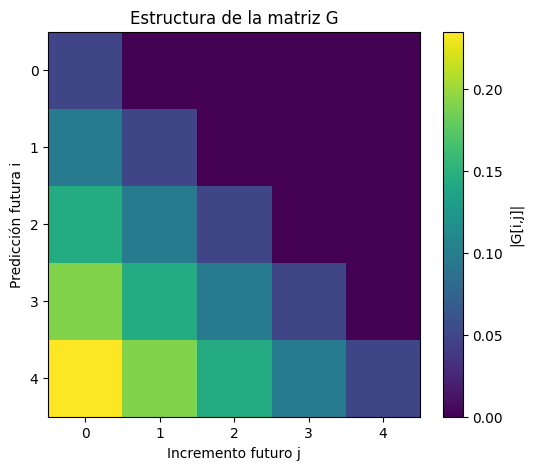

G shape: (5, 5)
F shape: (5, 2)

Primera columna de G:
[0.04938  0.097541 0.144513 0.190325 0.235006]


In [12]:
# Visualización de la estructura de G y F

plt.figure(figsize=(6, 5))
plt.imshow(np.abs(G), aspect="auto")
plt.colorbar(label="|G[i,j]|")
plt.xlabel("Incremento futuro j")
plt.ylabel("Predicción futura i")
plt.title("Estructura de la matriz G")
plt.show()

print("G shape:", G.shape)
print("F shape:", F.shape)
print("\nPrimera columna de G:")
print(G[:, 0])

### Relación con la respuesta escalón

Las transparencias indican que la primera columna de $G$ también puede obtenerse a partir de los coeficientes de la respuesta escalón.

Para esta planta,

\begin{align*}
G_{:,1}
=
\begin{bmatrix}
g_1 &
g_2 &
\cdots &
g_h
\end{bmatrix}^{T}.
\end{align*}

Comprobaremos numéricamente esta relación.

In [13]:
def discrete_step_coefficients(Ad, Bd, horizon):
    x = 0.0
    coeffs = []

    for _ in range(horizon):
        x = Ad * x + Bd
        coeffs.append(x)

    return np.asarray(coeffs)


g_step = discrete_step_coefficients(Ad, Bd, horizon)

print("Primera columna de G:")
print(G[:, 0])
print()
print("Coeficientes de respuesta escalón:")
print(g_step)
print()
print(
    "Diferencia máxima:",
    np.max(np.abs(G[:, 0] - g_step))
)

Primera columna de G:
[0.04938  0.097541 0.144513 0.190325 0.235006]

Coeficientes de respuesta escalón:
[0.04938  0.097541 0.144513 0.190325 0.235006]

Diferencia máxima: 2.7755575615628914e-17


> **Pregunta 29.** ¿Qué demuestra que la primera columna de $G$ coincida con la respuesta escalón?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Que, aunque GPC se derive con polinomios $A$, $B$, $E_j$ y $F_j$, la dinámica que utiliza sigue siendo la misma dinámica entrada–salida del proceso que también aparece en DMC.

</details>

> **Pregunta 30.** Entonces, ¿GPC y DMC utilizan modelos completamente ajenos entre sí?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

No. La representación es distinta, pero ambas describen la misma dinámica. DMC almacena explícitamente una secuencia larga de respuesta escalón; GPC la genera implícitamente desde una descripción polinómica compacta.

</details>

## 7. Función objetivo

La función de coste del GPC es

\begin{align*}
J
=
(\hat{\mathbf y}-\mathbf w)^T
(\hat{\mathbf y}-\mathbf w)
+
\lambda
{\Delta\mathbf u^+}^{T}
\Delta\mathbf u^+.
\end{align*}

El parámetro $\lambda$ penaliza las variaciones de la acción de control.

La referencia futura es

\begin{align*}
\mathbf w
=
\begin{bmatrix}
w(k+1) &
w(k+2) &
\cdots &
w(k+h)
\end{bmatrix}^{T},
\end{align*}

ya que en este ejemplo $d=0$.

Sin restricciones, la solución analítica es

\begin{align*}
\Delta\mathbf u^*
=
\left(
G^T G
+
\lambda I
\right)^{-1}
G^T
(\mathbf w-\mathbf f).
\end{align*}

Definiendo

\begin{align*}
K
=
\left(
G^T G
+
\lambda I
\right)^{-1}
G^T,
\end{align*}

solo se aplica la primera fila:

\begin{align*}
\Delta u(k)
=
[K]_1
(\mathbf w-\mathbf f).
\end{align*}

Finalmente,

\begin{align*}
u(k)
=
u(k-1)
+
\Delta u(k).
\end{align*}

In [14]:
lam = 0.1

K = np.linalg.solve(
    G.T @ G + lam * np.eye(horizon),
    G.T
)

K1 = K[0, :]

print("K1 =")
print(K1)

K1 =
[0.303292 0.465533 0.541013 0.572327 0.588517]


### Preguntas para dinamizar — función objetivo

> **Pregunta 31.** ¿Qué dos objetivos compiten en la función de coste GPC?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

El seguimiento de referencia y la suavidad de los incrementos de control:

\begin{align*}
J=
\|\hat{\mathbf y}-\mathbf w\|_2^2
+
\lambda\|\Delta\mathbf u^+\|_2^2.
\end{align*}

</details>

> **Pregunta 32.** ¿Qué sucede si $\lambda$ es muy pequeña?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

El controlador da prioridad al seguimiento y acepta incrementos de control mayores.

</details>

> **Pregunta 33.** ¿Qué sucede si $\lambda$ es muy grande?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Los incrementos se penalizan fuertemente; la acción es más suave pero el seguimiento tiende a ser más lento.

</details>

> **Pregunta 34.** ¿Penalizar $\Delta u$ significa penalizar también mantener una entrada constante distinta de cero?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

No. Una vez alcanzada una entrada constante,

\begin{align*}
\Delta u=0,
\end{align*}

por lo que no existe coste incremental por mantenerla.

</details>

> **Pregunta 35.** ¿Por qué se utiliza `np.linalg.solve()` en vez de invertir explícitamente $G^TG+\lambda I$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque resolver directamente el sistema lineal es numéricamente preferible y evita calcular una inversa innecesaria.

</details>

In [15]:
# Experimento en directo: efecto de lambda sobre K1 y el condicionamiento

lambda_demo = [0.0, 0.001, 0.01, 0.1, 0.5, 1.0, 10.0]

for lam_test in lambda_demo:
    M = G.T @ G + lam_test * np.eye(horizon)
    try:
        K_test = np.linalg.solve(M, G.T)
        K1_test = K_test[0, :]
        print(
            f"lambda={lam_test:7.3g}  "
            f"||K1||2={np.linalg.norm(K1_test):9.4f}  "
            f"cond={np.linalg.cond(M):12.4e}"
        )
    except np.linalg.LinAlgError:
        print(f"lambda={lam_test:7.3g} -> matriz singular")

lambda=      0  ||K1||2=  20.2510  cond=  1.2468e+03
lambda=  0.001  ||K1||2=   8.9089  cond=  1.9697e+02
lambda=   0.01  ||K1||2=   3.1432  cond=  2.3829e+01
lambda=    0.1  ||K1||2=   1.1293  cond=  3.3211e+00
lambda=    0.5  ||K1||2=   0.4852  cond=  1.4649e+00
lambda=      1  ||K1||2=   0.2871  cond=  1.2325e+00
lambda=     10  ||K1||2=   0.0345  cond=  1.0233e+00


## 8. Simulación GPC en horizonte deslizante

En cada instante se realiza:

1. lectura de $y(k)$;
2. construcción de $\mathbf y^-$;
3. cálculo de la respuesta libre $\mathbf f$;
4. construcción de la referencia futura $\mathbf w$;
5. cálculo de la secuencia óptima $\Delta\mathbf u^*$;
6. aplicación únicamente de $\Delta u(k)$;
7. actualización de $u(k)$;
8. avance de la planta y repetición del cálculo.

Para este ejemplo concreto, como $n_b=0$, no es necesario mantener un buffer de incrementos pasados para calcular la respuesta libre. Esa es una diferencia importante respecto a DMC, cuyo buffer depende del truncamiento $N_t$.

In [16]:
def future_reference(ref, k, horizon):
    w = np.empty(horizon)

    for j in range(1, horizon + 1):
        idx = min(k + j, len(ref) - 1)
        w[j - 1] = ref[idx]

    return w


def filtered_reference(ref, k, horizon, yk, alpha):
    w = np.empty(horizon)
    previous = yk

    for j in range(1, horizon + 1):
        idx = min(k + j, len(ref) - 1)
        previous = alpha * previous + (1.0 - alpha) * ref[idx]
        w[j - 1] = previous

    return w


def simulate_gpc(
    Ad, Bd, Cd, Dd,
    A_poly, B_poly, C_poly,
    horizon, lam, ref,
    alpha=None
):
    G, F, E_list, F_list, G_list, nb = create_gpc_matrices(
        A_poly, B_poly, C_poly, horizon
    )

    if nb != 0:
        raise NotImplementedError(
            "Esta práctica implementa la planta del ejemplo, para la que nb=0."
        )

    K = np.linalg.solve(
        G.T @ G + lam * np.eye(horizon),
        G.T
    )

    N = len(ref) - 1

    y = np.zeros(N + 1)
    u = np.zeros(N)
    du = np.zeros(N)

    pred_log = np.zeros((N, horizon))
    w_log = np.zeros((N, horizon))
    du_seq_log = np.zeros((N, horizon))

    x = 0.0
    y_prev = 0.0
    u_prev = 0.0

    for k in range(N):
        y[k] = Cd * x + Dd * u_prev

        y_minus = np.array([y[k], y_prev])
        f = F @ y_minus

        if alpha is None:
            w = future_reference(ref, k, horizon)
        else:
            w = filtered_reference(ref, k, horizon, y[k], alpha)

        du_seq = K @ (w - f)
        y_pred = G @ du_seq + f

        duk = float(du_seq[0])
        uk = u_prev + duk

        du[k] = duk
        u[k] = uk

        pred_log[k, :] = y_pred
        w_log[k, :] = w
        du_seq_log[k, :] = du_seq

        x = Ad * x + Bd * uk

        y_prev = y[k]
        u_prev = uk

    y[N] = Cd * x + Dd * u_prev

    return {
        "y": y,
        "u": u,
        "du": du,
        "G": G,
        "F": F,
        "K": K,
        "pred": pred_log,
        "w": w_log,
        "du_seq": du_seq_log,
    }

### Preguntas para dinamizar — horizonte deslizante

> **Pregunta 36.** ¿Qué calcula realmente el optimizador: $u(k)$ o $\Delta u(k)$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Calcula la secuencia futura de incrementos $\Delta\mathbf u^+$. La entrada absoluta se reconstruye mediante

\begin{align*}
u(k)=u(k-1)+\Delta u(k).
\end{align*}

</details>

> **Pregunta 37.** ¿Por qué solo se aplica el primer elemento de $\Delta\mathbf u^*$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque en la siguiente muestra se dispone de nueva información y se vuelve a resolver el problema. Esa es la idea de horizonte deslizante.

</details>

> **Pregunta 38.** ¿Qué ocurre con el resto de la secuencia calculada?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Se descarta como acción ejecutable. Solo sirve como parte del cálculo óptimo actual; en la siguiente muestra se genera una nueva secuencia.

</details>

> **Pregunta 39.** ¿Qué ventaja proporciona recalcular frente a aplicar toda la secuencia en lazo abierto?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Permite corregir perturbaciones, errores de modelado y diferencias entre la predicción y la evolución real.

</details>

## 9. Referencia de simulación

Las transparencias del ejemplo muestran simulaciones de $200$ pasos y cambios de referencia.

Para esta práctica se adopta, una referencia que pasa de $0$ a $1$ en $k=20$:

\begin{align*}
r(k)
=
\begin{cases}
0, & k<20, \\
1, & k\geq20.
\end{cases}
\end{align*}

Esto permite observar claramente la anticipación producida por el conocimiento de la referencia futura.

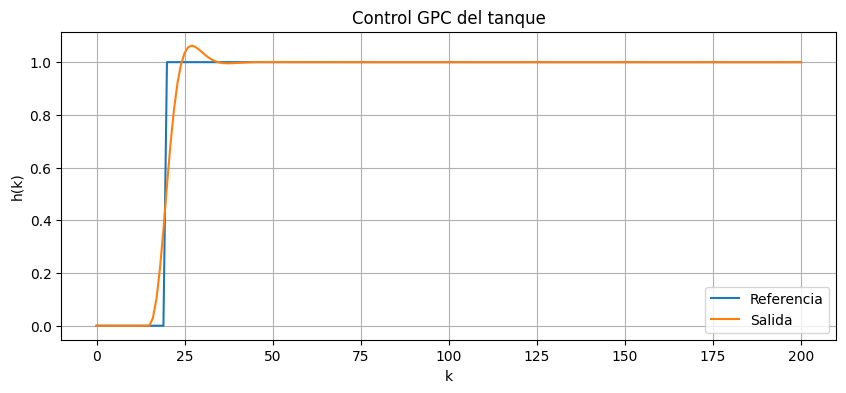

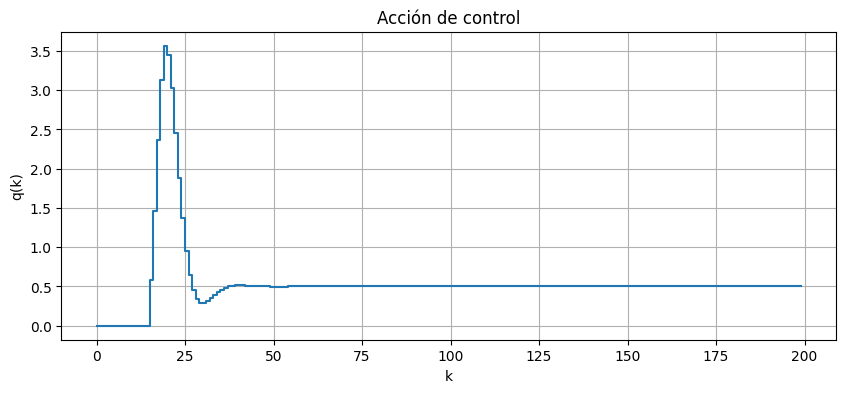

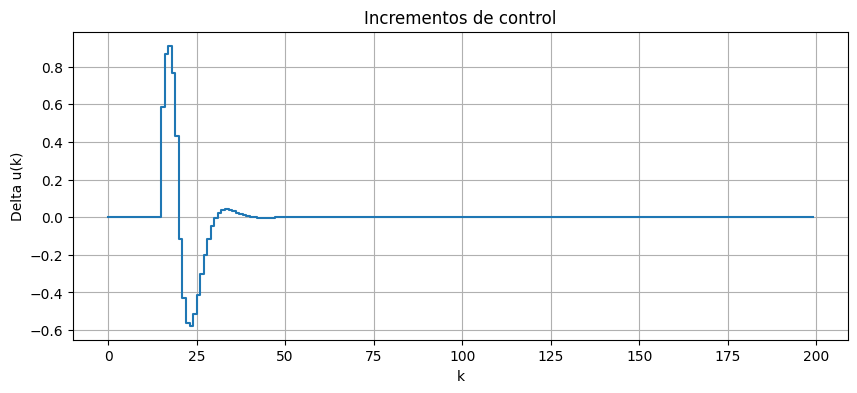

In [17]:
N = 200
k_change = 20

ref = np.zeros(N + 1)
ref[k_change:] = 1.0

result = simulate_gpc(
    Ad, Bd, Cd, Dd,
    A_poly, B_poly, C_poly,
    horizon=5,
    lam=0.1,
    ref=ref
)

k_y = np.arange(N + 1)
k_u = np.arange(N)

plt.figure(figsize=(10, 4))
plt.plot(k_y, ref, label="Referencia")
plt.plot(k_y, result["y"], label="Salida")
plt.xlabel("k")
plt.ylabel("h(k)")
plt.title("Control GPC del tanque")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.step(k_u, result["u"], where="post")
plt.xlabel("k")
plt.ylabel("q(k)")
plt.title("Acción de control")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.step(k_u, result["du"], where="post")
plt.xlabel("k")
plt.ylabel("Delta u(k)")
plt.title("Incrementos de control")
plt.grid(True)
plt.show()

### Preguntas para dinamizar — referencia futura

> **Pregunta 40.** Si el cambio ocurre en $k=20$ y $h=5$, ¿cuándo puede empezar a verlo el controlador?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Cuando el cambio entra en el vector de referencia futura. Con la convención del notebook, puede influir varios pasos antes de $k=20$.

</details>

> **Pregunta 41.** ¿Por qué puede cambiar la acción de control antes de que cambie la referencia actual?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque GPC conoce $\mathbf w=[w(k+1),\ldots,w(k+h)]^T$ y puede anticipar el cambio utilizando el modelo.

</details>

> **Pregunta 42.** ¿Qué pasaría si el controlador solo conociese $r(k)$ y lo repitiese a lo largo de todo el horizonte?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Perdería la anticipación de cambios conocidos. Seguiría siendo predictivo respecto a la planta, pero no respecto a la referencia.

</details>

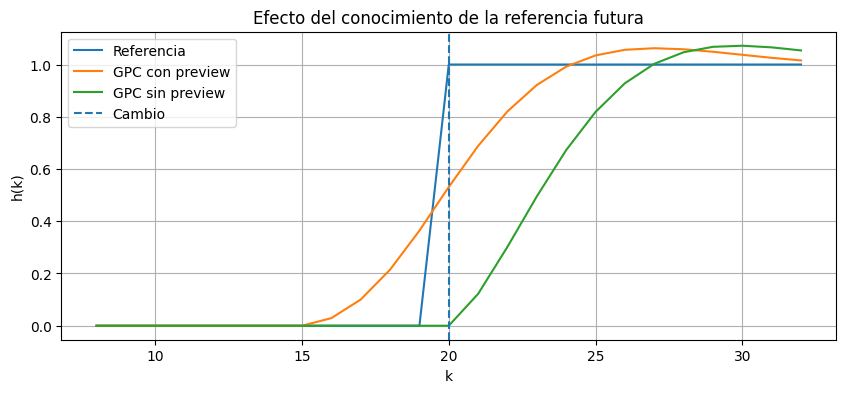

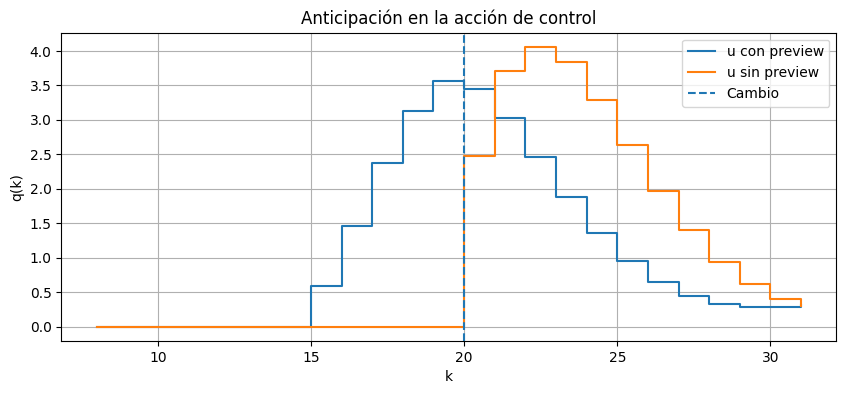

In [18]:
# Experimento en directo: GPC con y sin preview de referencia

def held_reference(ref, k, horizon):
    return np.full(horizon, ref[min(k, len(ref)-1)])

def simulate_gpc_no_preview(
    Ad, Bd, Cd, Dd,
    A_poly, B_poly, C_poly,
    horizon, lam, ref
):
    G_np, F_np, *_ = create_gpc_matrices(
        A_poly, B_poly, C_poly, horizon
    )
    K_np = np.linalg.solve(
        G_np.T @ G_np + lam * np.eye(horizon),
        G_np.T
    )

    N_np = len(ref) - 1
    y = np.zeros(N_np + 1)
    u = np.zeros(N_np)
    du = np.zeros(N_np)

    x = 0.0
    y_prev = 0.0
    u_prev = 0.0

    for k in range(N_np):
        y[k] = Cd * x + Dd * u_prev
        y_minus = np.array([y[k], y_prev])
        f = F_np @ y_minus
        w = held_reference(ref, k, horizon)

        du_seq = K_np @ (w - f)
        duk = float(du_seq[0])
        uk = u_prev + duk

        du[k] = duk
        u[k] = uk
        x = Ad * x + Bd * uk

        y_prev = y[k]
        u_prev = uk

    y[N_np] = Cd * x + Dd * u_prev
    return y, u, du

res_preview = simulate_gpc(
    Ad, Bd, Cd, Dd,
    A_poly, B_poly, C_poly,
    horizon=5, lam=0.1, ref=ref
)
y_no_prev, u_no_prev, _ = simulate_gpc_no_preview(
    Ad, Bd, Cd, Dd,
    A_poly, B_poly, C_poly,
    horizon=5, lam=0.1, ref=ref
)

window = 12
sl_y = slice(k_change-window, k_change+window+1)
sl_u = slice(k_change-window, k_change+window)

plt.figure(figsize=(10, 4))
plt.plot(k_y[sl_y], ref[sl_y], label="Referencia")
plt.plot(k_y[sl_y], res_preview["y"][sl_y], label="GPC con preview")
plt.plot(k_y[sl_y], y_no_prev[sl_y], label="GPC sin preview")
plt.axvline(k_change, linestyle="--", label="Cambio")
plt.xlabel("k")
plt.ylabel("h(k)")
plt.title("Efecto del conocimiento de la referencia futura")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.step(k_u[sl_u], res_preview["u"][sl_u], where="post", label="u con preview")
plt.step(k_u[sl_u], u_no_prev[sl_u], where="post", label="u sin preview")
plt.axvline(k_change, linestyle="--", label="Cambio")
plt.xlabel("k")
plt.ylabel("q(k)")
plt.title("Anticipación en la acción de control")
plt.grid(True)
plt.legend()
plt.show()

## 10. Visualización de una predicción

El horizonte permite al controlador utilizar información de referencia futura.

Como el cambio de referencia ocurre en $k=20$ y se utiliza $h=5$, el GPC empieza a verlo antes de que el cambio llegue al instante actual.

Se representa la predicción calculada en $k=17$.

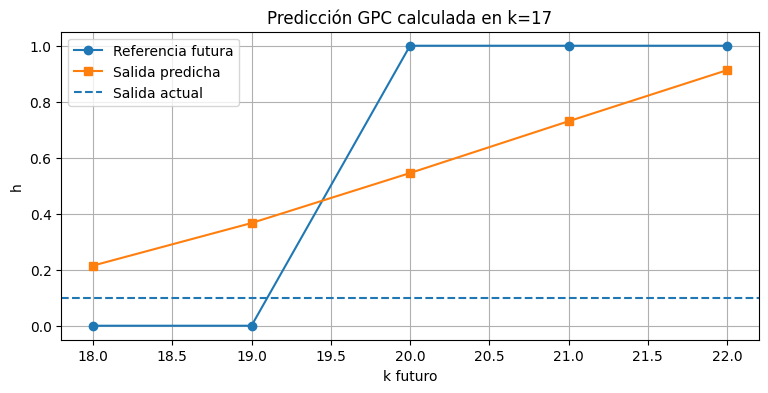

Secuencia futura de incrementos calculada:
[0.911745 0.818254 0.613696 0.218284 0.043075]

Solo se aplica el primer valor:
0.9117445066075752


In [19]:
k_inspect = 17
future_k = np.arange(k_inspect + 1, k_inspect + 1 + 5)

plt.figure(figsize=(9, 4))
plt.plot(future_k, result["w"][k_inspect], "o-", label="Referencia futura")
plt.plot(future_k, result["pred"][k_inspect], "s-", label="Salida predicha")
plt.axhline(result["y"][k_inspect], linestyle="--", label="Salida actual")
plt.xlabel("k futuro")
plt.ylabel("h")
plt.title(f"Predicción GPC calculada en k={k_inspect}")
plt.grid(True)
plt.legend()
plt.show()

print("Secuencia futura de incrementos calculada:")
print(result["du_seq"][k_inspect])
print()
print("Solo se aplica el primer valor:")
print(result["du_seq"][k_inspect, 0])

> **Pregunta 43.** En $k=17$, ¿qué representan los cinco puntos de la curva de salida predicha?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Son las estimaciones

\begin{align*}
\hat y(k+1|k),\ldots,\hat y(k+5|k)
\end{align*}

calculadas usando la información disponible en $k=17$ y la secuencia óptima de incrementos.

</details>

> **Pregunta 44.** ¿La secuencia mostrada en `du_seq` se aplicará completa?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

No. Solo se aplica su primer valor. Los demás son decisiones hipotéticas necesarias para evaluar el futuro durante la optimización actual.

</details>

> **Pregunta 45.** Si en $k=18$ la planta se desvía de lo predicho, ¿qué ocurre?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Se vuelve a medir la salida y se recalcula una nueva secuencia óptima. El horizonte deslizante corrige la predicción anterior.

</details>

## 11. Experimento A — Efecto del horizonte $h$

Las transparencias comparan, para $\lambda=0.1$,

\begin{align*}
h=1,\qquad h=5,\qquad h=10.
\end{align*}

Se reproducirá esa comparación.

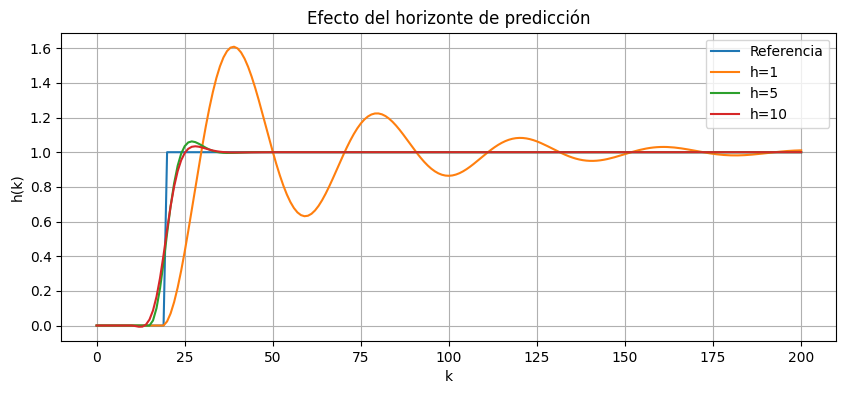

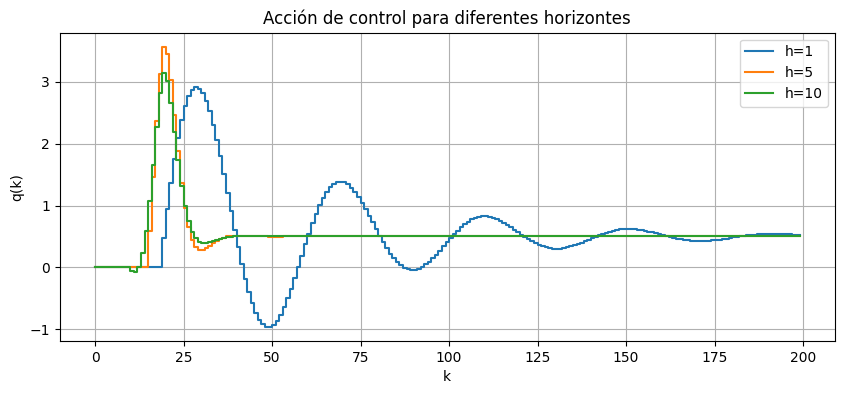

In [20]:
h_values = [1, 5, 10]
lam_h = 0.1

plt.figure(figsize=(10, 4))
plt.plot(k_y, ref, label="Referencia")

results_h = {}

for h_test in h_values:
    res = simulate_gpc(
        Ad, Bd, Cd, Dd,
        A_poly, B_poly, C_poly,
        horizon=h_test,
        lam=lam_h,
        ref=ref
    )
    results_h[h_test] = res
    plt.plot(k_y, res["y"], label=f"h={h_test}")

plt.xlabel("k")
plt.ylabel("h(k)")
plt.title("Efecto del horizonte de predicción")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))

for h_test in h_values:
    plt.step(
        k_u,
        results_h[h_test]["u"],
        where="post",
        label=f"h={h_test}"
    )

plt.xlabel("k")
plt.ylabel("q(k)")
plt.title("Acción de control para diferentes horizontes")
plt.grid(True)
plt.legend()
plt.show()

### Preguntas para dinamizar — efecto del horizonte $h$

> **Pregunta 46.** ¿Qué diferencia de anticipación esperáis entre $h=1$, $h=5$ y $h=10$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Con horizontes mayores, el cambio de referencia entra antes en la ventana de predicción y puede influir antes en la acción actual.

</details>

> **Pregunta 47.** ¿Un horizonte mayor implica siempre una respuesta más rápida?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

No necesariamente. El resultado depende también de $\lambda$ y de la dinámica. Un horizonte mayor aporta más información, pero no garantiza una mejora ilimitada.

</details>

> **Pregunta 48.** ¿Qué coste introduce aumentar $h$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Aumentan el tamaño de $G$, el número de variables futuras y el coste de resolver el problema.

</details>

> **Pregunta 49.** ¿Qué significado tendría $h=0$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

No habría predicción futura ni problema predictivo que optimizar.

</details>

In [21]:
# Cuantificación del efecto de h

print("h      max|du|       max|u|      error final")
print("---------------------------------------------")

for h_test in h_values:
    res = results_h[h_test]
    e_final = np.mean(ref[-20:] - res["y"][-20:])
    print(
        f"{h_test:2d}     "
        f"{np.max(np.abs(res['du'])):10.6f}   "
        f"{np.max(np.abs(res['u'])):10.6f}   "
        f"{e_final:+12.8f}"
    )

h      max|du|       max|u|      error final
---------------------------------------------
 1       0.482048     2.908375    +0.00431495
 5       0.911745     3.565460    +0.00000000
10       0.615433     3.144666    +0.00000000


> **Pregunta 50.** ¿A partir de qué $h$ las mejoras parecen pequeñas en este ejemplo?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Debe decidirse observando las curvas y las métricas del experimento. No existe un valor universal.

</details>

> **Pregunta 51.** Si la planta tuviese un tiempo muerto importante, ¿qué requisito impondría sobre $h$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

El horizonte debería extenderse más allá del tiempo muerto para que el controlador pueda observar en la predicción el efecto de las acciones actuales.

</details>

## 12. Experimento B — Efecto de $\lambda$

Las transparencias del ejemplo comparan, con $h=5$,

\begin{align*}
\lambda
\in
\left\{
0,\,
0.01,\,
0.4,\,
0.5,\,
1,\,
10
\right\}.
\end{align*}

Una $\lambda$ pequeña da más peso al seguimiento, mientras que una $\lambda$ grande penaliza con mayor intensidad los cambios de la acción de control.

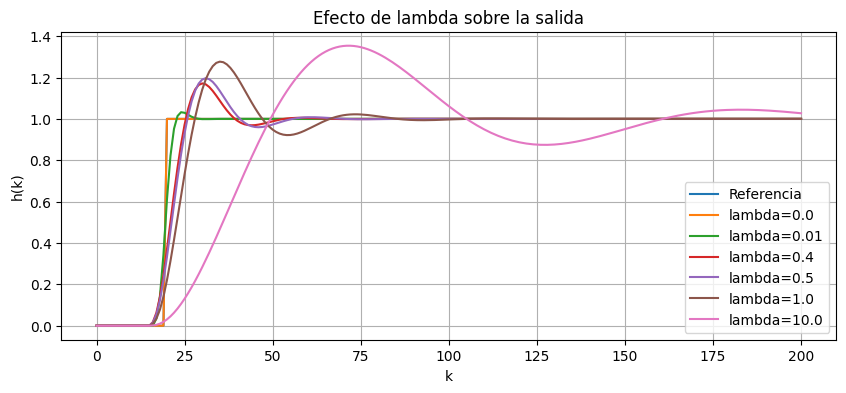

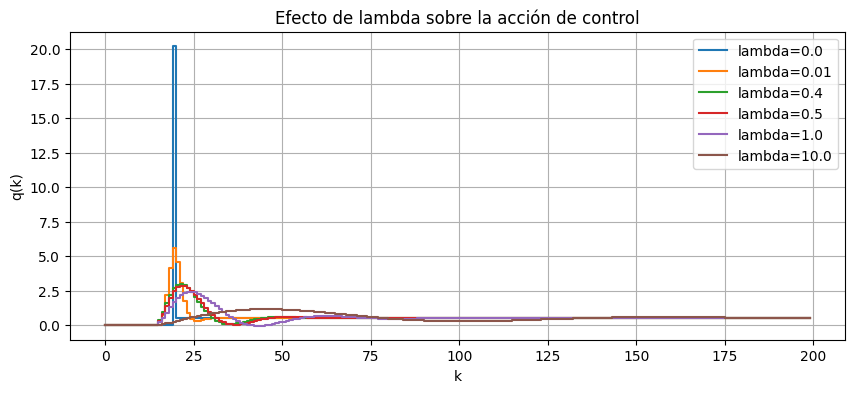

In [22]:
lambda_values = [0.0, 0.01, 0.4, 0.5, 1.0, 10.0]
h_lambda = 5

results_lambda = {}

plt.figure(figsize=(10, 4))
plt.plot(k_y, ref, label="Referencia")

for lam_test in lambda_values:
    res = simulate_gpc(
        Ad, Bd, Cd, Dd,
        A_poly, B_poly, C_poly,
        horizon=h_lambda,
        lam=lam_test,
        ref=ref
    )
    results_lambda[lam_test] = res
    plt.plot(k_y, res["y"], label=f"lambda={lam_test}")

plt.xlabel("k")
plt.ylabel("h(k)")
plt.title("Efecto de lambda sobre la salida")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))

for lam_test in lambda_values:
    plt.step(
        k_u,
        results_lambda[lam_test]["u"],
        where="post",
        label=f"lambda={lam_test}"
    )

plt.xlabel("k")
plt.ylabel("q(k)")
plt.title("Efecto de lambda sobre la acción de control")
plt.grid(True)
plt.legend()
plt.show()

### Preguntas para dinamizar — efecto de $\lambda$

> **Pregunta 52.** ¿Qué caso esperáis que produzca los mayores incrementos de control: $\lambda=0$ o $\lambda=10$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

$\lambda=0$, porque no existe penalización explícita sobre $\Delta u$.

</details>

> **Pregunta 53.** ¿Qué sucede con la rapidez de seguimiento al aumentar $\lambda$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Normalmente disminuye porque el controlador reparte la corrección en incrementos más pequeños.

</details>

> **Pregunta 54.** ¿Puede utilizarse $\lambda$ para garantizar un límite duro sobre $\Delta u$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

No. $\lambda$ solo penaliza los incrementos. Para garantizar límites hay que introducir restricciones explícitas.

</details>

> **Pregunta 55.** ¿Qué otro papel cumple un $\lambda>0$ además de modificar la agresividad?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Regulariza la matriz $G^TG+\lambda I$ y puede mejorar su condicionamiento numérico.

</details>

In [23]:
# Cuantificación del efecto de lambda

print("lambda      max|du|       max|u|       error final")
print("--------------------------------------------------")

for lam_test in lambda_values:
    res = results_lambda[lam_test]
    e_final = np.mean(ref[-20:] - res["y"][-20:])
    print(
        f"{lam_test:7.3f}   "
        f"{np.max(np.abs(res['du'])):10.6f}   "
        f"{np.max(np.abs(res['u'])):10.6f}   "
        f"{e_final:+12.8f}"
    )

lambda      max|du|       max|u|       error final
--------------------------------------------------
  0.000    20.251042    20.251042    +0.00000000
  0.010     1.933139     5.573360    +0.00000000
  0.400     0.649209     2.973446    +0.00000000
  0.500     0.587424     2.846819    -0.00000000
  1.000     0.413412     2.432183    -0.00000666
 10.000     0.066742     1.150072    -0.03874269


> **Pregunta 56.** ¿Existe un valor universalmente óptimo de $\lambda$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

No. Depende del compromiso deseado entre seguimiento, suavidad del actuador y robustez numérica.

</details>

> **Pregunta 57.** ¿Por qué conviene analizar simultáneamente salida, $u$ y $\Delta u$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque una sintonización puede producir buen seguimiento a costa de movimientos excesivos del actuador. Observar solo la salida ocultaría ese compromiso.

</details>

## 13. Experimento C — Filtrado de referencia

Las transparencias introducen una referencia filtrada

\begin{align*}
w(k+j)
=
\alpha w(k+j-1)
+
(1-\alpha)r(k+j),
\end{align*}

con

\begin{align*}
w(k)=y(k).
\end{align*}

Para $h=5$ y $\lambda=0.1$ se comparan

\begin{align*}
\alpha
\in
\left\{
0,\,
0.1,\,
0.5,\,
0.9
\right\}.
\end{align*}

Cuando $\alpha=0$ no existe suavizado y se utiliza directamente la referencia futura.

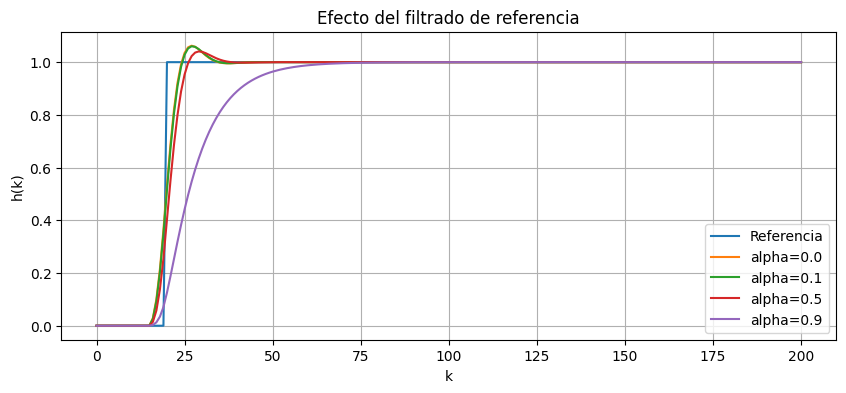

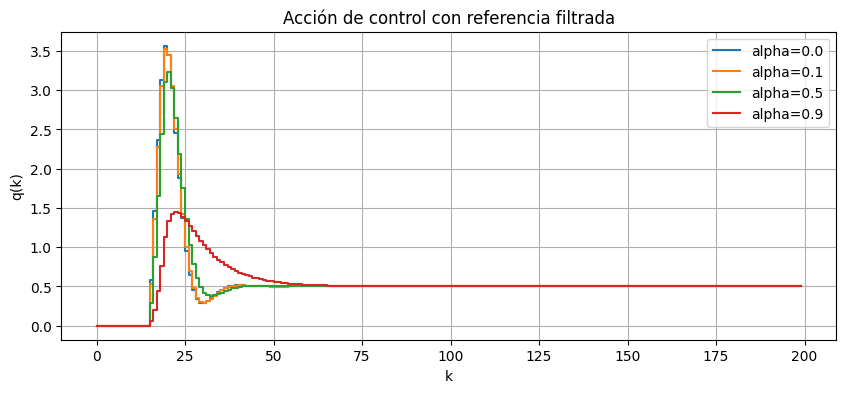

In [24]:
alpha_values = [0.0, 0.1, 0.5, 0.9]
h_alpha = 5
lam_alpha = 0.1

results_alpha = {}

plt.figure(figsize=(10, 4))
plt.plot(k_y, ref, label="Referencia")

for alpha in alpha_values:
    res = simulate_gpc(
        Ad, Bd, Cd, Dd,
        A_poly, B_poly, C_poly,
        horizon=h_alpha,
        lam=lam_alpha,
        ref=ref,
        alpha=alpha
    )
    results_alpha[alpha] = res
    plt.plot(k_y, res["y"], label=f"alpha={alpha}")

plt.xlabel("k")
plt.ylabel("h(k)")
plt.title("Efecto del filtrado de referencia")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))

for alpha in alpha_values:
    plt.step(
        k_u,
        results_alpha[alpha]["u"],
        where="post",
        label=f"alpha={alpha}"
    )

plt.xlabel("k")
plt.ylabel("q(k)")
plt.title("Acción de control con referencia filtrada")
plt.grid(True)
plt.legend()
plt.show()

### Preguntas para dinamizar — filtrado de referencia

> **Pregunta 58.** ¿Qué representa $\alpha$ en el filtro de referencia?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Controla cuánto peso conserva la trayectoria filtrada anterior frente al nuevo valor de referencia:

\begin{align*}
w(k+j)=\alpha w(k+j-1)+(1-\alpha)r(k+j).
\end{align*}

</details>

> **Pregunta 59.** ¿Qué ocurre con $\alpha=0$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

No hay suavizado:

\begin{align*}
w(k+j)=r(k+j).
\end{align*}

</details>

> **Pregunta 60.** ¿Qué esperáis para $\alpha=0.9$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Una trayectoria interna mucho más suave, movimientos menores y normalmente un seguimiento más lento.

</details>

> **Pregunta 61.** ¿Aumentar $\alpha$ es equivalente a aumentar $\lambda$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

No. $\alpha$ modifica la referencia que ve el optimizador; $\lambda$ modifica la función de coste penalizando $\Delta u$.

</details>

In [25]:
# Cuantificación del efecto de alpha

print("alpha      max|du|       max|u|       error final")
print("-------------------------------------------------")

for alpha in alpha_values:
    res = results_alpha[alpha]
    e_final = np.mean(ref[-20:] - res["y"][-20:])
    print(
        f"{alpha:5.2f}     "
        f"{np.max(np.abs(res['du'])):10.6f}   "
        f"{np.max(np.abs(res['u'])):10.6f}   "
        f"{e_final:+12.8f}"
    )

alpha      max|du|       max|u|       error final
-------------------------------------------------
 0.00       0.911745     3.565460    +0.00000000
 0.10       0.906792     3.529942    +0.00000000
 0.50       0.795971     3.226802    +0.00000000
 0.90       0.373728     1.450435    +0.00000001


> **Pregunta 62.** ¿Por qué puede ser útil filtrar la referencia aunque ya exista $\lambda$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque son dos grados de libertad distintos: uno modifica la trayectoria deseada y otro el coste de mover el actuador. Esto permite separar parcialmente la forma de la consigna del compromiso de control.

</details>

> **Pregunta 63.** ¿Qué inconveniente puede tener un $\alpha$ excesivamente alto?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Puede volver innecesariamente lenta la respuesta y retrasar el seguimiento de cambios de consigna.

</details>

## 14. Comparación GPC — DMC

Existe una relación estrecha entre GPC y DMC.

En DMC, la dinámica se representa mediante una secuencia larga de coeficientes de respuesta escalón y la respuesta libre requiere un buffer asociado al truncamiento $N_t$.

En GPC, la planta se representa de forma compacta mediante

\begin{align*}
A(z^{-1})
\quad\text{y}\quad
B(z^{-1}),
\end{align*}

y los datos pasados necesarios dependen principalmente de los órdenes $n_a$ y $n_b$.

Para el tanque de esta práctica,

\begin{align*}
n_a=1,
\qquad
n_b=0.
\end{align*}

Por tanto, la respuesta libre solo necesita

\begin{align*}
y(k)
\quad\text{y}\quad
y(k-1).
\end{align*}

Sin embargo, la matriz dinámica $G$ puede interpretarse también mediante los coeficientes de la respuesta escalón, como se ha comprobado anteriormente.

### Actividad

Explique por qué GPC puede utilizar una descripción mucho más compacta de la planta que DMC y, al mismo tiempo, producir una matriz dinámica $G$ relacionada con la misma respuesta escalón.

### Preguntas para dinamizar — comparación GPC y DMC

> **Pregunta 64.** ¿Cuál es la diferencia principal en la representación de la planta?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

DMC almacena una secuencia de respuesta escalón $g_i$. GPC utiliza los polinomios compactos $A(z^{-1})$ y $B(z^{-1})$ dentro de un modelo CARIMA.

</details>

> **Pregunta 65.** ¿Qué ventaja de memoria tiene GPC para esta planta?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

La respuesta libre utiliza solo $y(k)$ y $y(k-1)$ porque $n_a=1$ y $n_b=0$, mientras que DMC necesita un buffer ligado al truncamiento $N_t$.

</details>

> **Pregunta 66.** Si las representaciones son distintas, ¿por qué la primera columna de $G$ coincide con la respuesta escalón?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque ambas formulaciones representan la misma dinámica física. GPC genera esos coeficientes de forma implícita a partir del modelo polinómico.

</details>

> **Pregunta 67.** ¿Qué elemento adicional aparece de forma explícita en la formulación GPC estudiada?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

El modelo CARIMA de perturbaciones, incluido mediante

\begin{align*}
C(z^{-1})\frac{e(t)}{1-z^{-1}}.
\end{align*}

</details>

## 15. Actividad final

Seleccione razonadamente los parámetros

\begin{align*}
T_d,\qquad
h,\qquad
\lambda,\qquad
\alpha
\end{align*}

para el tanque estudiado.

La justificación debe considerar:

- calidad del modelo discreto;
- longitud de la predicción;
- anticipación ante cambios conocidos de referencia;
- rapidez de seguimiento;
- amplitud y suavidad de $u(k)$;
- amplitud de $\Delta u(k)$;
- coste computacional.

### Entregable propuesto

Incluya:

1. los polinomios $A(z^{-1})$, $B(z^{-1})$ y $\widetilde A(z^{-1})$;
2. $E_1$, $F_1$, $E_2$, $F_2$ y $E_3$;
3. las matrices $G$ y $F$ para la configuración seleccionada;
4. gráfica de referencia y salida;
5. gráfica de $u(k)$;
6. gráfica de $\Delta u(k)$;
7. discusión del efecto de $h$, $\lambda$ y $\alpha$;
8. comparación breve entre GPC y DMC.

### Preguntas de síntesis antes de seleccionar los parámetros finales

> **Pregunta 68.** ¿Qué parámetros pertenecen principalmente al modelo y cuáles a la sintonización?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

- $T_d$ y los polinomios $A$, $B$, $C$: descripción del proceso y del modelo CARIMA.
- $h$: longitud de predicción.
- $\lambda$: compromiso entre seguimiento e incrementos de control.
- $\alpha$: suavizado de la referencia interna.

</details>

> **Pregunta 69.** ¿En qué orden tendría sentido tomar las decisiones de diseño?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Una secuencia razonable es:

1. elegir $T_d$ según la dinámica;
2. obtener/identificar $A$, $B$ y $C$;
3. verificar el predictor mediante la ecuación diofántica;
4. elegir $h$ para cubrir la dinámica relevante;
5. ajustar $\lambda$;
6. utilizar $\alpha$ si se desea suavizar la referencia.

</details>

> **Pregunta 70.** Si el seguimiento es malo, ¿por qué no deberíamos modificar inmediatamente $\lambda$?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

Porque antes conviene comprobar que el modelo CARIMA y el predictor son correctos y que $h$ cubre suficientemente la dinámica.

</details>

> **Pregunta 71.** ¿Qué comprobación del notebook os da confianza en la implementación matemática del predictor?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

La verificación del residuo de la ecuación diofántica y la comprobación independiente de que la primera columna de $G$ coincide con la respuesta escalón.

</details>

> **Pregunta 72.** Si tuvierais que resumir GPC en una sola frase, ¿cuál sería?

<details>
<summary><b>Respuesta / comentario docente</b></summary>

GPC utiliza un modelo CARIMA y predictores obtenidos mediante ecuaciones diofánticas para calcular, en cada muestra, la secuencia de incrementos de control que optimiza el seguimiento futuro frente al esfuerzo de control, aplicando solo el primer incremento en horizonte deslizante.

</details>

## 16. Notas de implementación

La implementación Python se ha construido directamente a partir de la formulación de las transparencias:

\begin{align*}
C
=
E_j\Delta A
+
z^{-j}F_j,
\end{align*}

\begin{align*}
G_j
=
E_jB,
\end{align*}

\begin{align*}
\hat{\mathbf y}
=
G\Delta\mathbf u^+
+
\mathbf f,
\end{align*}

y

\begin{align*}
\Delta\mathbf u^*
=
\left(
G^T G+\lambda I
\right)^{-1}
G^T
(\mathbf w-\mathbf f).
\end{align*}

Esto permite que el alumno vea explícitamente el paso desde la ecuación diofántica hasta la ley de control.